# Data Connection From MYSQL Workbench to Python

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

# 1. Connection Details
USER = 'root'
PASSWORD = 'your_password_here'  # Replace with your actual password
HOST = '127.0.0.1'
PORT = '3306'
DB_NAME = 'zomato_db'

# 2. Connection String (MySQL syntax)
safe_pass = urllib.parse.quote_plus(PASSWORD)
engine = create_engine(f'mysql+pymysql://{USER}:{safe_pass}@{HOST}:{PORT}/{DB_NAME}')

# 3. Load the View into a DataFrame
try:
    query = "SELECT * FROM v_market_analysis_base"
    df = pd.read_sql(query, engine)
    print("✅ Data Loaded Successfully from MySQL!")
    print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
    display(df.head())
except Exception as e:
    print(f"❌ Connection Error: {e}")

✅ Data Loaded Successfully from MySQL!
Total Rows: 41665 | Total Columns: 11


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,category,city
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


### TASK 1: Data Cleaning

In [2]:
for col in ['rate', 'approx_cost', 'amount']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
            errors='coerce'
        )

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41665 entries, 0 to 41664
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          41665 non-null  str    
 1   online_order  41665 non-null  str    
 2   book_table    41665 non-null  str    
 3   rate          41665 non-null  float64
 4   votes         41665 non-null  int64  
 5   location      41665 non-null  str    
 6   rest_type     41516 non-null  str    
 7   cuisines      41654 non-null  str    
 8   approx_cost   41418 non-null  float64
 9   category      41665 non-null  str    
 10  city          41665 non-null  str    
dtypes: float64(2), int64(1), str(8)
memory usage: 3.5 MB


### TASK 2: IDENTITY EXTRACTION 

In [7]:
df['cuisine_count'] = df['cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

df['primary_type'] = df['rest_type'].apply(lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown')

print("✅ New Features Created: 'cuisine_count' and 'primary_type'")
display(df[['name', 'cuisines', 'cuisine_count', 'primary_type']].head())

✅ New Features Created: 'cuisine_count' and 'primary_type'


,name,cuisines,cuisine_count,primary_type
0,Jalsa,"North Indian, Mughlai, Chinese",3,Casual Dining
1,Spice Elephant,"Chinese, North Indian, Thai",3,Casual Dining
2,San Churro Cafe,"Cafe, Mexican, Italian",3,Cafe
3,Addhuri Udupi Bhojana,"South Indian, North Indian",2,Quick Bites
4,Grand Village,"North Indian, Rajasthani",2,Casual Dining


### TASK 3: BUDGET SEGMENTATION 

In [10]:
def segment_budget(cost):
    if cost <= 300: 
        return 'Budget (0-300)'
    elif cost <= 700: 
        return 'Mid-Range (301-700)'
    elif cost <= 1500: 
        return 'Premium (701-1500)'
    else: 
        return 'Luxury (1500+)'

df['budget_segment'] = df['approx_cost'].apply(segment_budget)

display(df[['name', 'cuisine_count', 'primary_type', 'budget_segment']].head())

,name,cuisine_count,primary_type,budget_segment
0,Jalsa,3,Casual Dining,Premium (701-1500)
1,Spice Elephant,3,Casual Dining,Premium (701-1500)
2,San Churro Cafe,3,Cafe,Premium (701-1500)
3,Addhuri Udupi Bhojana,2,Quick Bites,Budget (0-300)
4,Grand Village,2,Casual Dining,Mid-Range (301-700)


## Advanced Business Intelligence Visualization

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Styling for a professional look
plt.style.use('fivethirtyeight') 
sns.set_palette("viridis")

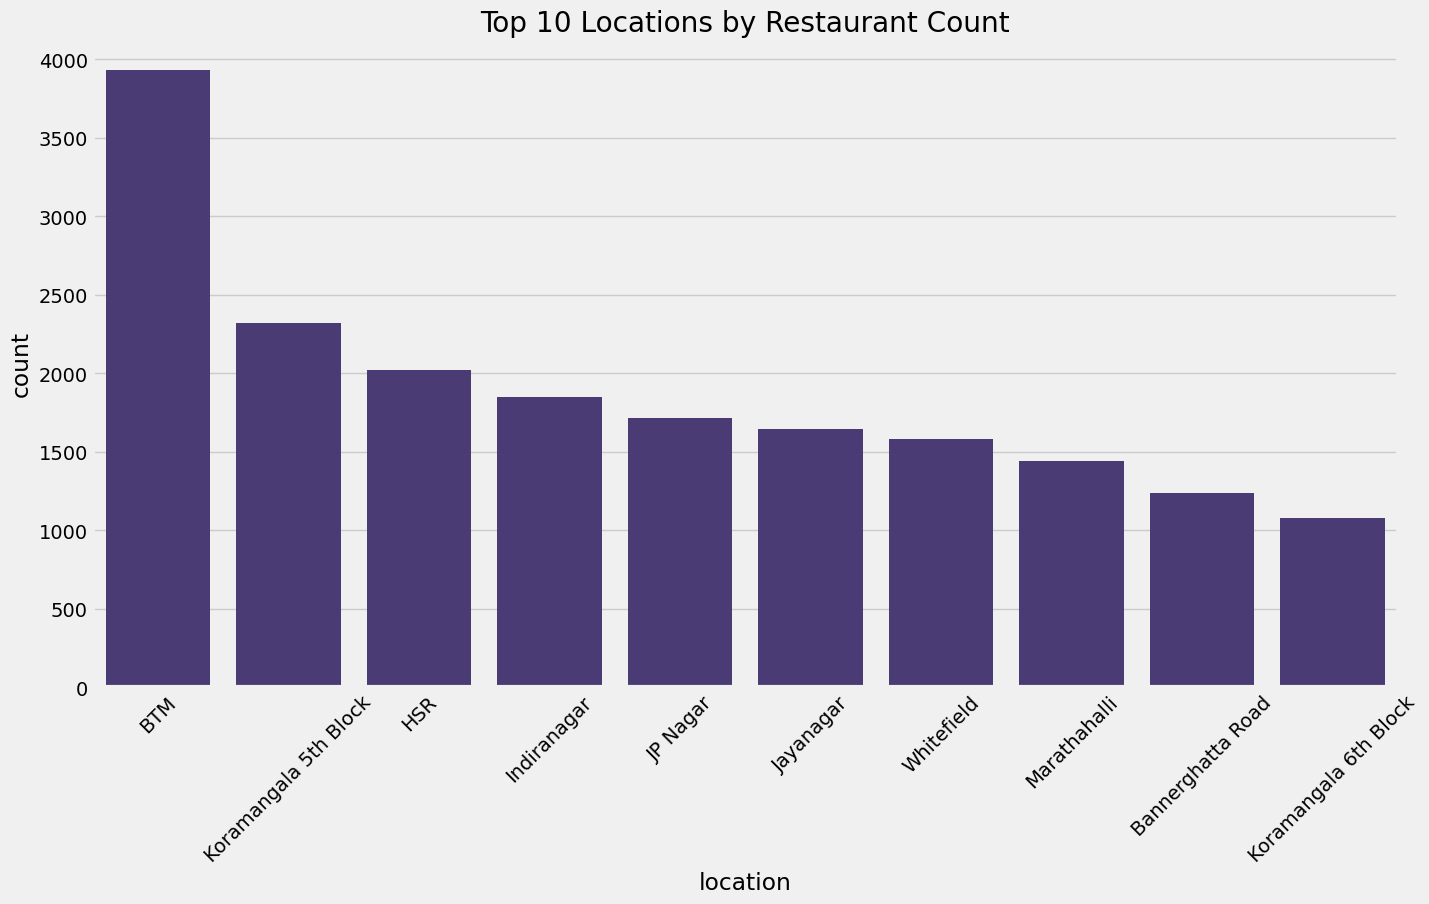

In [12]:
plt.figure(figsize=(15, 8))
sns.countplot(x='location', data=df, order=df['location'].value_counts().head(10).index)
plt.title('Top 10 Locations by Restaurant Count')
plt.xticks(rotation=45)
plt.show()

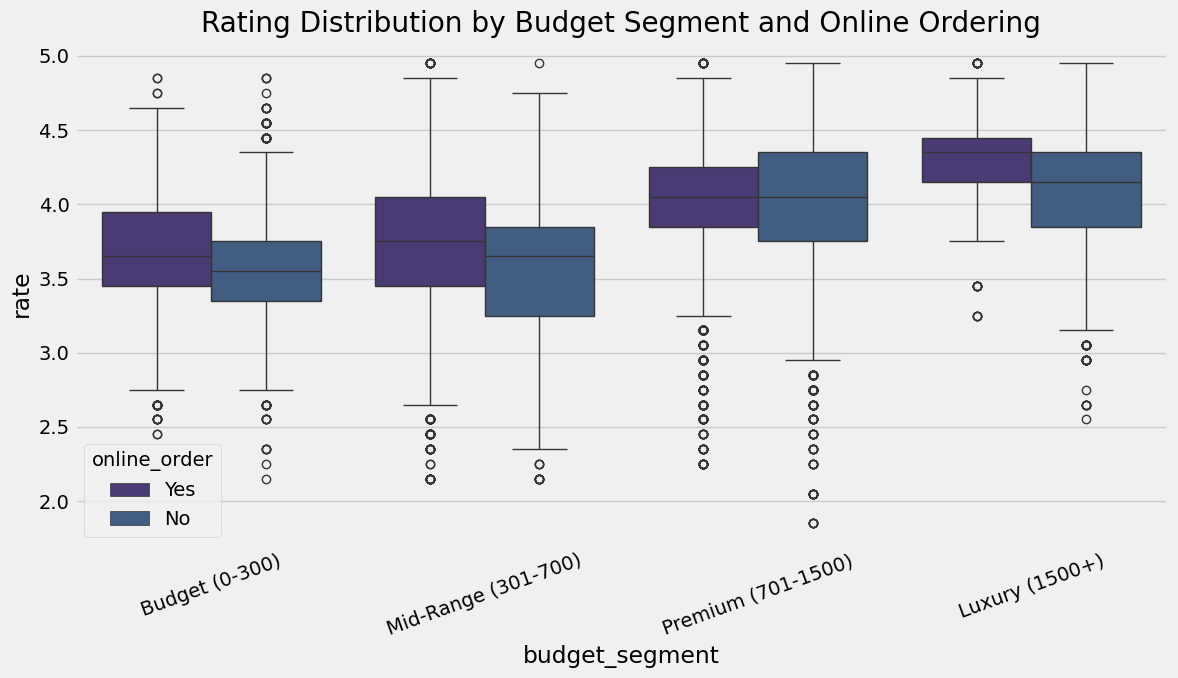

In [16]:

plt.figure(figsize=(12, 7))
sns.boxplot(
    x='budget_segment',
    y='rate',
    hue='online_order',
    data=df,
    order=['Budget (0-300)', 'Mid-Range (301-700)', 'Premium (701-1500)', 'Luxury (1500+)']
)
plt.title('Rating Distribution by Budget Segment and Online Ordering')
plt.xticks(rotation=20)
plt.tight_layout()


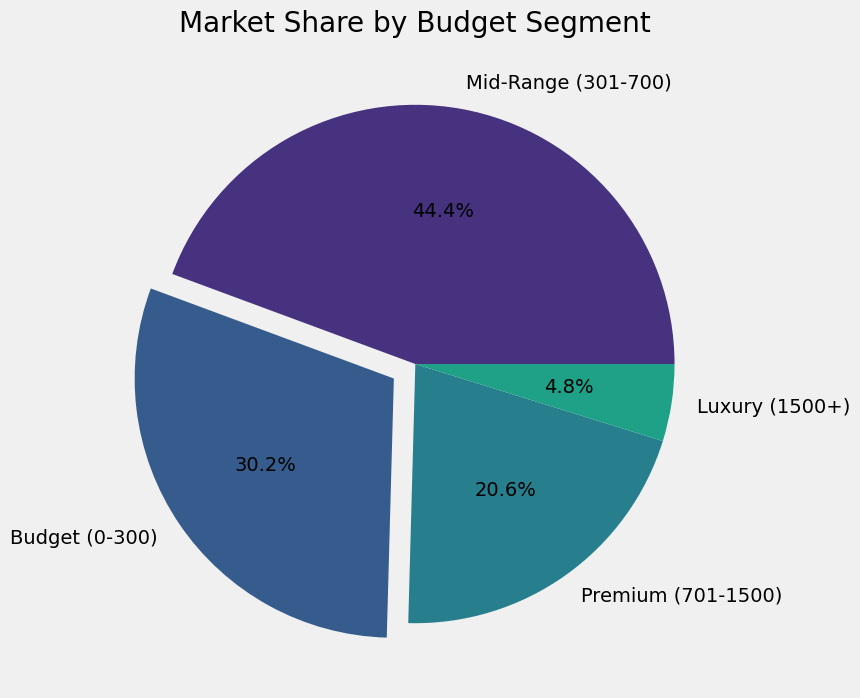

In [17]:
plt.figure(figsize=(8, 8))
df['budget_segment'].value_counts().plot.pie(autopct='%1.1f%%', explode=[0, 0.1, 0, 0])
plt.title('Market Share by Budget Segment')
plt.show()

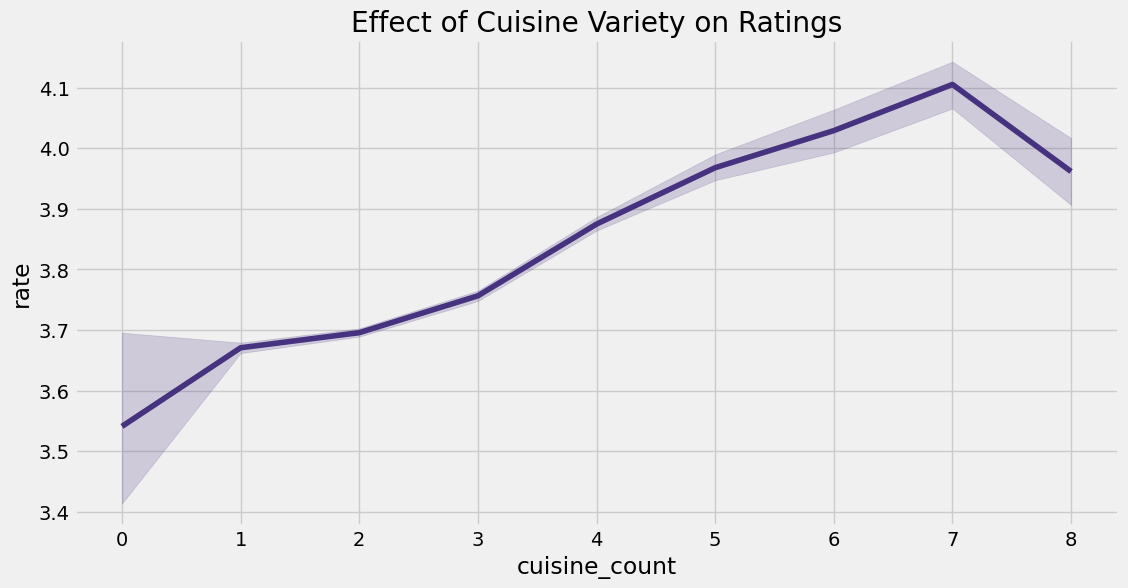

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='cuisine_count', y='rate', data=df)
plt.title('Effect of Cuisine Variety on Ratings')
plt.show()

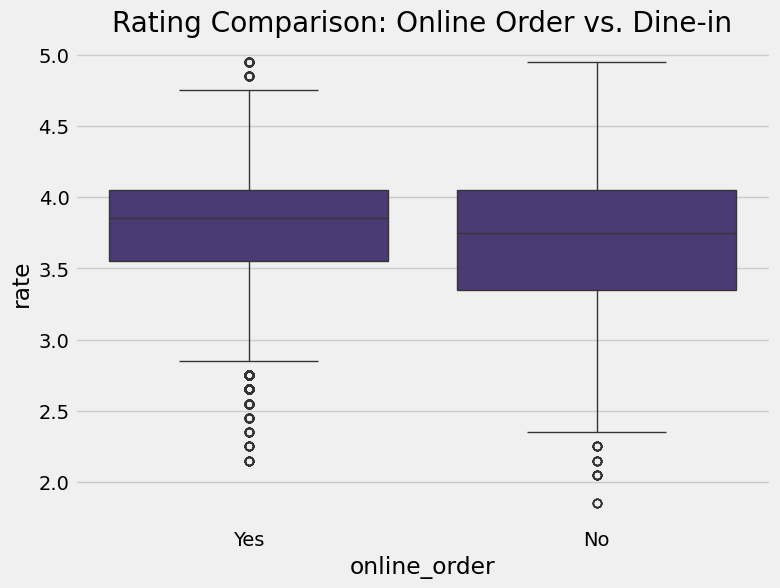

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='online_order', y='rate', data=df)
plt.title('Rating Comparison: Online Order vs. Dine-in')
plt.show()

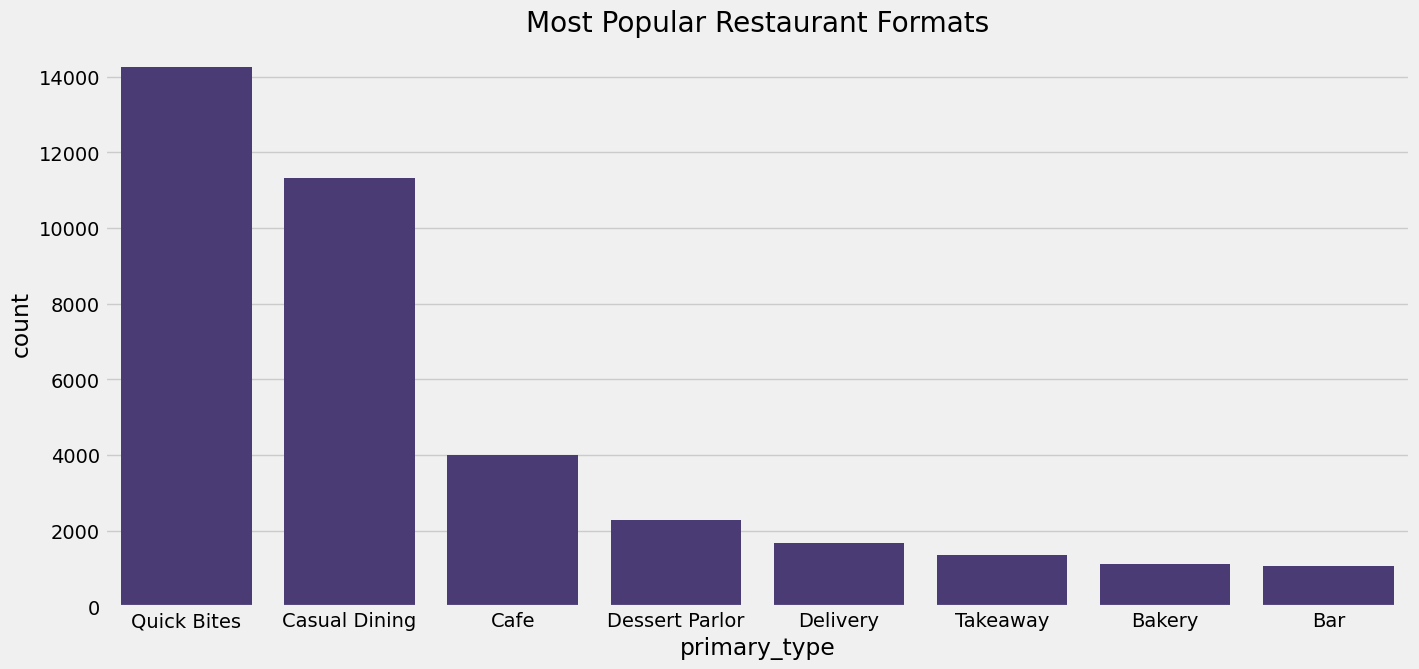

In [22]:
plt.figure(figsize=(15, 7))
sns.countplot(x='primary_type', data=df, order=df['primary_type'].value_counts().head(8).index)
plt.title('Most Popular Restaurant Formats')
plt.show()

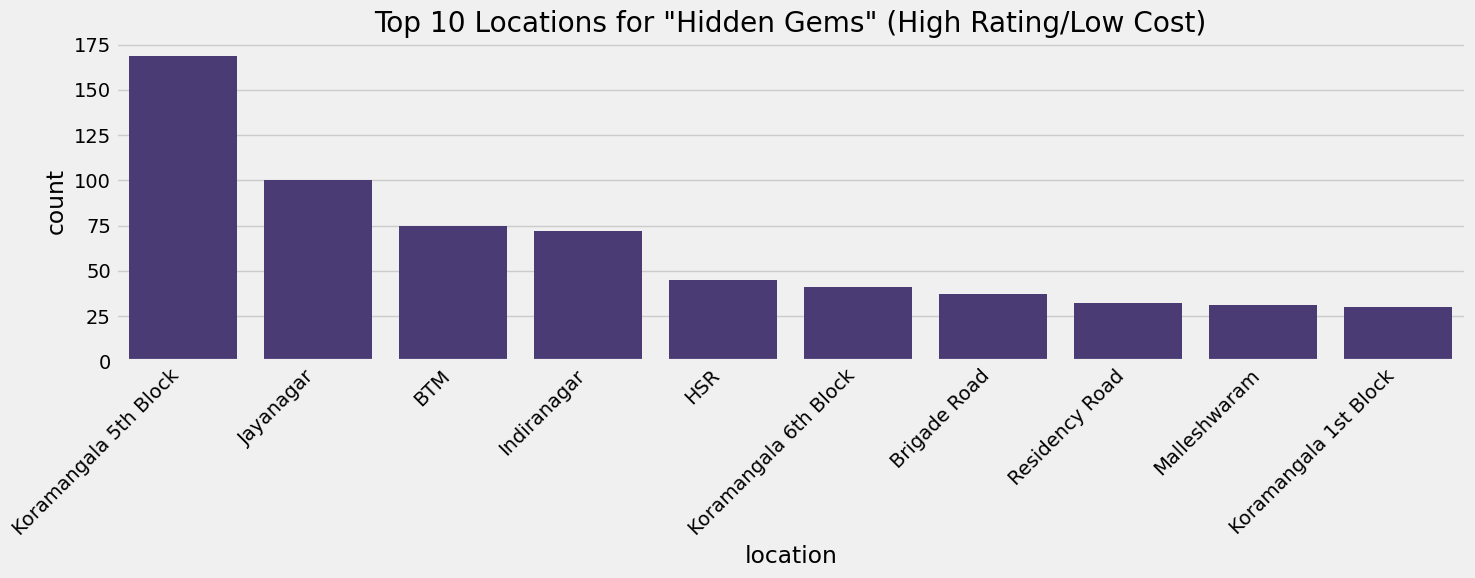

In [24]:
budget_gems = df[(df['approx_cost'] <= 400) & (df['rate'] >= 4.2)]
plt.figure(figsize=(15, 6))
sns.countplot(x='location', data=budget_gems, order=budget_gems['location'].value_counts().head(10).index)
plt.title('Top 10 Locations for "Hidden Gems" (High Rating/Low Cost)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

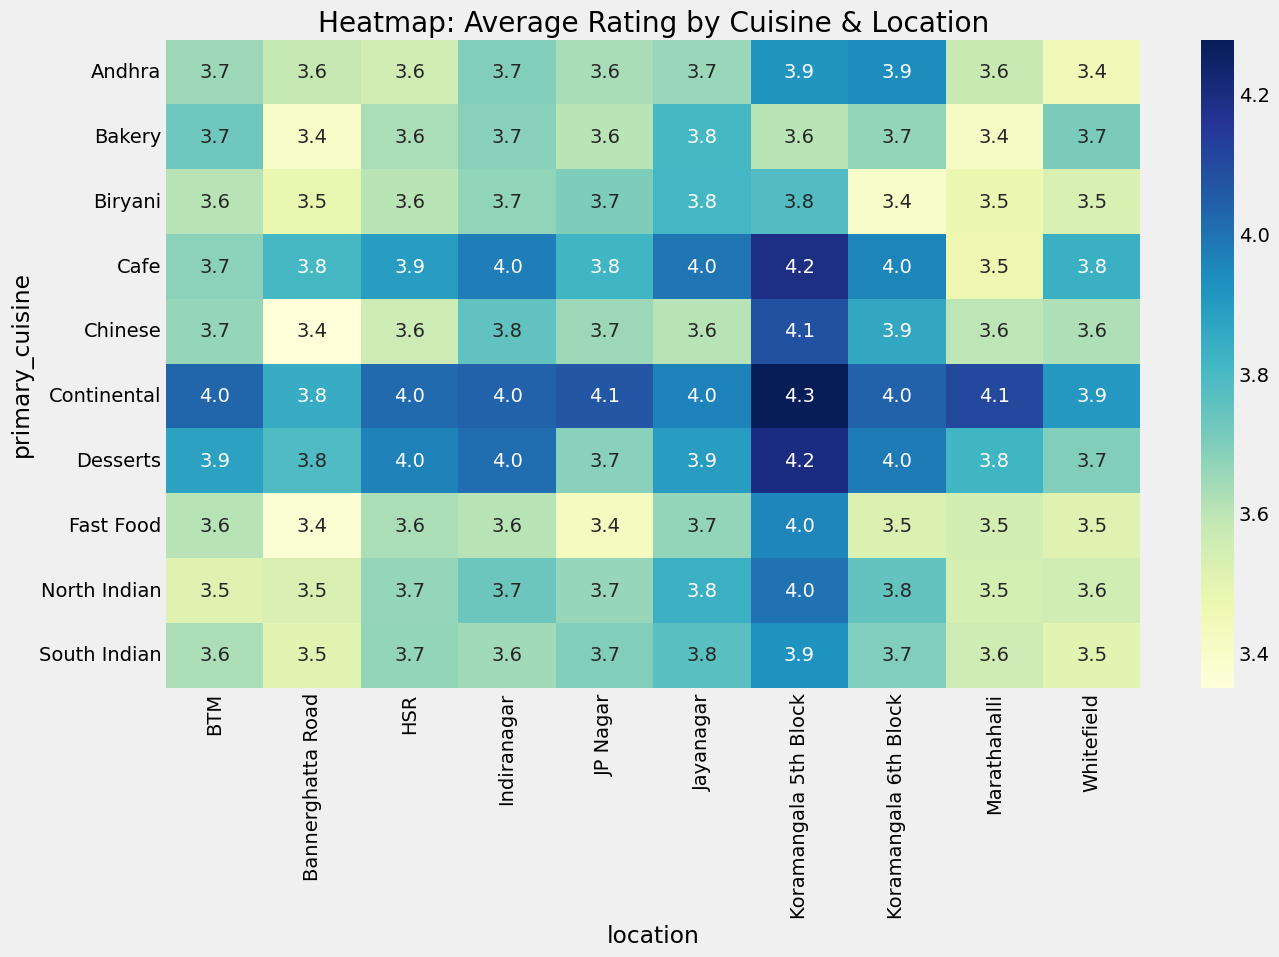

In [27]:
# Top 10 locations aur Top 10 cuisines ka matrix
top_locations = df['location'].value_counts().head(10).index
top_cuisines = df['cuisines'].str.split(', ', expand=True)[0].value_counts().head(10).index

# Filter and Pivot
pivot_df = df[df['location'].isin(top_locations)]
# Simple logic to get primary cuisine
pivot_df['primary_cuisine'] = pivot_df['cuisines'].str.split(', ').str[0]
pivot_table = pivot_df[pivot_df['primary_cuisine'].isin(top_cuisines)].pivot_table(
    index='primary_cuisine', columns='location', values='rate', aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title('Heatmap: Average Rating by Cuisine & Location')
plt.show()

C:\Users\swati\AppData\Local\Temp\ipykernel_19892\567127161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='budget_segment', y='rate', data=df, palette="Set2")


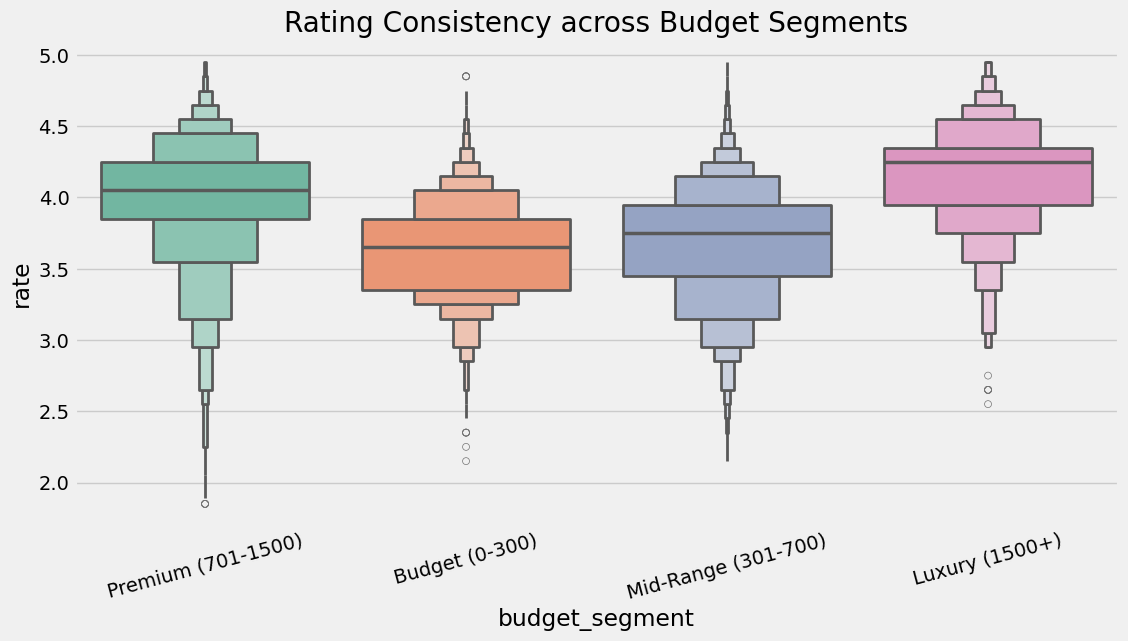

In [33]:
plt.figure(figsize=(12, 6))
sns.boxenplot(x='budget_segment', y='rate', data=df, palette="Set2")
plt.title('Rating Consistency across Budget Segments')
plt.xticks(rotation=15)
plt.show()

C:\Users\swati\AppData\Local\Temp\ipykernel_19892\2132090141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cuisine_group', y='rate', data=df, inner="quart", palette="pastel")


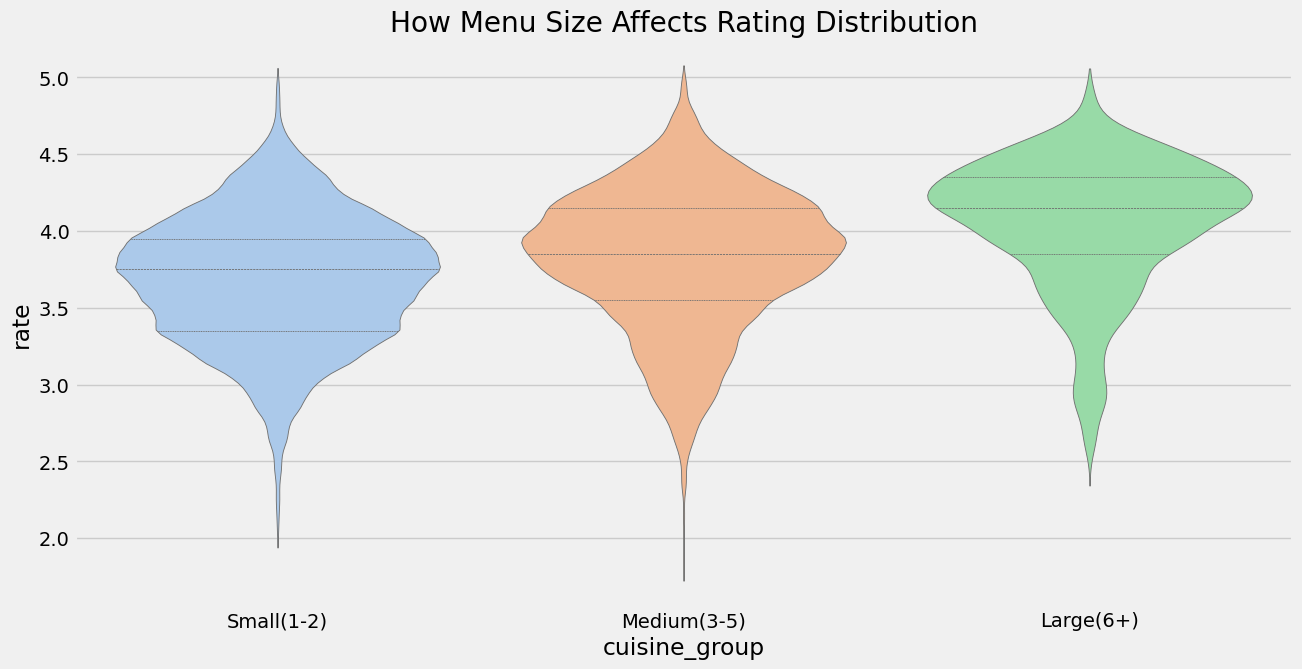

In [36]:
plt.figure(figsize=(14, 7))
# Hum cuisine_count ko bins mein daal dete hain clear view ke liye
df['cuisine_group'] = pd.cut(df['cuisine_count'], bins=[0, 2, 5, 10], labels=['Small(1-2)', 'Medium(3-5)', 'Large(6+)'])

sns.violinplot(x='cuisine_group', y='rate', data=df, inner="quart", palette="pastel")
plt.title('How Menu Size Affects Rating Distribution')
plt.show()

## 🎯 Key Insights & Project Conclusion

1. **Data Pipeline:** Successfully established a secure connection using `SQLAlchemy` and fetched over 41,000+ restaurant records directly from the MySQL database.
2. **Data Cleaning:** Handled messy text data in the `rate` and `approx_cost` columns, converting them into clean numeric formats for accurate calculations.
3. **Feature Engineering:** - Extracted `primary_type` from multiple restaurant combinations.
   - Computed `cuisine_count` to measure menu diversity.
   - Segmented the market into 4 clear price brackets: *Budget, Mid-Range, Premium, and Luxury*.
4. **Next Steps:** The processed dataset with newly engineered features is fully optimized and ready to be loaded into Power BI to build interactive Executive Dashboards.